In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer



In [ ]:
# Discretization(Binning) of continuous features
# Binning is of 3 types:
#1. Supervised Binning - Decision Tree Binning
#2. Unsupervised Binning - Equal Width Binning(Uniform), Equal Frequency Binning(quantile), Kmeans Binning, 
#3, Custom Binning

# EQUAL WIDTH BINNING
# here number of bins is decided by the user and the width of each bin is same
# bin width = (max value - min value)/number of bins

# in this outliers will be handled, but the span or the distribution of the data will be the same as the original data

# QUARTILE BINNING
# here number of intervals is decided by the user and the width of each interval is not same
# suppose user says 10 intervals, then the data will be divided into 10 equal parts and each part will have 10% of the data
# matlab pehle interval meio waha tak values aayengi jaha tak 10 percent of data na ho jaye, then next interval will start from there and will go till 20% of data is there and so on just like quartiles
# par har interval mei no of values will be the same but the width of the interval will be different
# in this outliears are handled and distribution is made normal


# KMEANS BINNING

# here e use k means clustering algorithm to find the optimal number of bins and the width of each bin



# Let's do binning on Titanic Dataset

In [2]:
df = pd.read_csv('titanic.csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.dropna(inplace = True)
df.shape

(714, 3)

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
X = df.drop(columns=['Survived'], axis = 1)
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [8]:
clf = DecisionTreeClassifier()

In [9]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.6293706293706294

In [10]:
np.mean(cross_val_score(clf, X, y, cv = 10, scoring = 'accuracy'))

np.float64(0.6373435054773083)

In [11]:
kbin_age = KBinsDiscretizer(n_bins = 10, encode = 'ordinal', strategy = 'quantile') # strategy = 'quantile' means we are doing equal frequency binning, strategy can be uniform or quantile or kmeans
# encoding can be ordinal or one hot
kbin_fare = KBinsDiscretizer(n_bins = 10, encode = 'ordinal', strategy = 'quantile')

In [12]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1]) # index of columns in X
])

In [13]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)
trf.named_transformers_['first'].bin_edges_ # to see the bin edges for age column
trf.named_transformers_['second'].bin_edges_ # to see the bin edges for fare column

c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [14]:
clf.fit(X_train_trf, y_train)
y_pred_trf = clf.predict(X_test_trf)
accuracy_score(y_test, y_pred_trf)

0.6223776223776224

In [15]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(clf, X_trf, y, cv = 10, scoring = 'accuracy'))

c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.682140062597809)

FUNCTION TO DO JUST THE SAME WE DID ABOVE

In [16]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6289123630672926


c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\gurpr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization

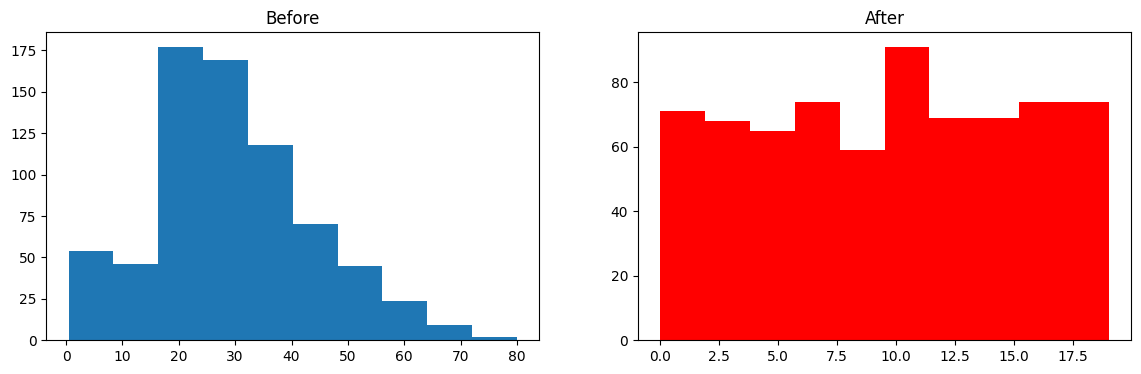

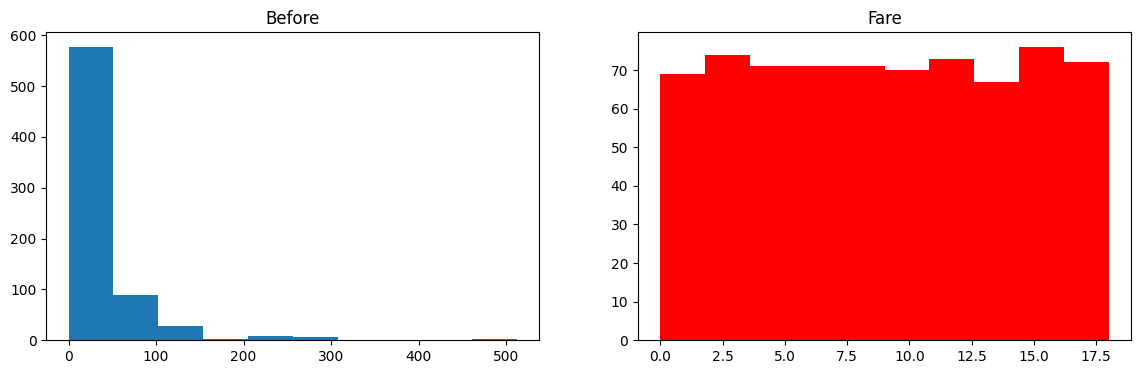

In [24]:
discretize(20, 'quantile')